In [19]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

In [20]:
df = pd.read_csv(
    "../data/processed/nasa_fd001_rul.csv"
)

print(df.shape)

(20631, 20)


In [21]:
features = [
    col
    for col in df.columns
    if col not in ["unit", "RUL"]
]

X = df[features]
y = df["RUL"]

print(X.shape)

(20631, 18)


In [22]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(20631, 18)


In [23]:
sequence_length = 30

X_sequences = []
y_sequences = []

for i in range(
    sequence_length,
    len(X_scaled)
):
    X_sequences.append(
        X_scaled[
            i-sequence_length:i
        ]
    )

    y_sequences.append(
        y.iloc[i]
    )

X_sequences = np.array(
    X_sequences
)

y_sequences = np.array(
    y_sequences
)

print(X_sequences.shape)

(20601, 30, 18)


In [24]:
split_index = int(
    len(X_sequences) * 0.8
)

X_train = X_sequences[:split_index]
X_test = X_sequences[split_index:]

y_train = y_sequences[:split_index]
y_test = y_sequences[split_index:]

print(X_train.shape)
print(X_test.shape)

(16480, 30, 18)
(4121, 30, 18)


In [25]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

print(tf.__version__)

2.21.0


In [26]:
model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(30,18)
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)

])

model.summary()

c:\Users\KOMAL NIKAM\code\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("Model Compiled")

Model Compiled


In [28]:
print(X_train.shape)
print(X_test.shape)

(16480, 30, 18)
(4121, 30, 18)


In [29]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(30,18)
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)

])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("Model Compiled")

Model Compiled


In [31]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_test,
        y_test
    ),
    epochs=10,
    batch_size=64
)

Epoch 1/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - loss: 9999.0713 - mae: 79.7834 - val_loss: 8693.1807 - val_mae: 72.0199
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 4659.3550 - mae: 55.7253 - val_loss: 6413.6177 - val_mae: 64.8530
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 4423.9839 - mae: 55.0260 - val_loss: 6374.3408 - val_mae: 64.7938
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 4436.3027 - mae: 55.1957 - val_loss: 6404.8389 - val_mae: 64.8387
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 4411.5483 - mae: 54.9994 - val_loss: 6418.4634 - val_mae: 64.8614
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 4421.1509 - mae: 55.0681 - val_loss: 6430.9595 - val_mae: 64.8827
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 4428.4087 - mae: 55.1473 - val_loss: 6439.5112 - val_mae: 64.8970
Epoch 8/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 4427.6235 - mae: 55.0654 - val_loss: 6380.2217 -

In [32]:
loss, mae = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("MAE:", mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2924.9224 - mae: 39.7532
Test Loss: 2924.92236328125
MAE: 39.75322341918945


In [33]:
predictions = model.predict(
    X_test
)

print(predictions[:10])

129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
[[98.65367 ]
 [92.92084 ]
 [81.432434]
 [83.297585]
 [79.049904]
 [75.28276 ]
 [78.26114 ]
 [83.22516 ]
 [82.30026 ]
 [77.0094  ]]


In [34]:
comparison = pd.DataFrame({
    "Actual_RUL": y_test[:20],
    "Predicted_RUL": predictions[:20].flatten()
})

comparison

,Actual_RUL,Predicted_RUL
0,81.0,98.653671
1,80.0,92.920837
2,79.0,81.432434
3,78.0,83.297585
4,77.0,79.049904
5,76.0,75.282761
6,75.0,78.261139
7,74.0,83.225159
8,73.0,82.300262
9,72.0,77.009399


In [35]:
def machine_status(rul):

    if rul > 100:
        return "Healthy"

    elif rul > 30:
        return "Warning"

    else:
        return "Critical"

In [36]:
comparison["Status"] = (
    comparison["Predicted_RUL"]
    .apply(machine_status)
)

comparison

,Actual_RUL,Predicted_RUL,Status
0,81.0,98.653671,Warning
1,80.0,92.920837,Warning
2,79.0,81.432434,Warning
3,78.0,83.297585,Warning
4,77.0,79.049904,Warning
5,76.0,75.282761,Warning
6,75.0,78.261139,Warning
7,74.0,83.225159,Warning
8,73.0,82.300262,Warning
9,72.0,77.009399,Warning


In [37]:
model.save(
    "../models/lstm_rul_model.keras"
)

print("LSTM Model Saved")

LSTM Model Saved


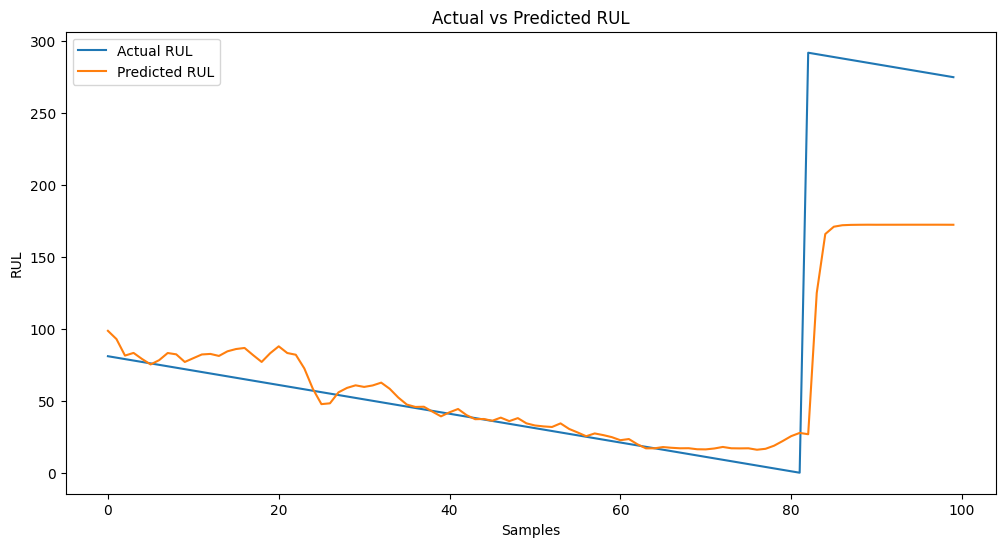

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test[:100],
    label="Actual RUL"
)

plt.plot(
    predictions[:100],
    label="Predicted RUL"
)

plt.legend()

plt.title(
    "Actual vs Predicted RUL"
)

plt.xlabel("Samples")

plt.ylabel("RUL")

plt.show()